In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# For getting and transforming the MNIST dataset
from torchvision import datasets
from torchvision import transforms

### Settings

In [2]:
RANDOM_SEED = 1
BATCH_SIZE = 128
NUM_EPOCHS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print(DEVICE)

cuda


### Optimizing Data Transfers in PyTorch
To get the best performance out of your GPU training, you should use pinned memory in combination with asynchronous transfers. This allows you to overlap data loading with model computation.
1. `pin_memory=True` (DataLoader)
By default, Python data resides in "pageable" CPU memory. Before the GPU can access this data, the CPU must first copy it into a temporary "pinned" (page-locked) buffer. See the DataLoader code below.
- **What it does:** Setting pin_memory=True in your DataLoader instructs PyTorch to allocate the data directly into pinned memory.
- **The Benefit:** It skips the extra staging step, enabling much faster and more direct data transfers from the CPU to the GPU.
2. `non_blocking=True` (.to() / .cuda())
Usually, when you move a tensor to the GPU, your code "blocks" (stops) until the transfer is finished. See the training code below.
- **What it does:** When used with pinned memory, non_blocking=True allows the CPU to initiate the transfer and immediately move to the next line of code without waiting.
- **The Benefit:** It "overlaps" the data transfer with other operations. While the GPU is receiving data for the next batch, the CPU can stay busy with other logic.

### Getting the dataset

In [3]:
train_dataset = datasets.MNIST(root='data', 
                               train=True, 
                               transform=transforms.ToTensor(),
                               download=True)

print(f"The length of train dataset: {len(train_dataset)}")

test_dataset = datasets.MNIST(root='data', 
                              train=False, 
                              transform=transforms.ToTensor())

print(f"The length of test dataset: {len(test_dataset)}")

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True,
                          pin_memory=True,
                          num_workers=4)

test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=False,
                         pin_memory=True,
                         num_workers=4)

# Checking the dataset
for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

The length of train dataset: 60000
The length of test dataset: 10000
Image batch dimensions: torch.Size([128, 1, 28, 28])
Image label dimensions: torch.Size([128])


**What happens in transforms.ToTensor()?**

- Input: a `PIL Image` or a `NumPy ndarray` with pixel values in the range [0, 255] (integers).

- Output: a `torch.FloatTensor` with values in [0.0, 1.0].

Internally, it:

- Converts the image (H, W, C) → tensor (C, H, W).

- Casts the values to `float32`.

- Divides every pixel by 255.0 so the range goes from [0, 255] → [0.0, 1.0].

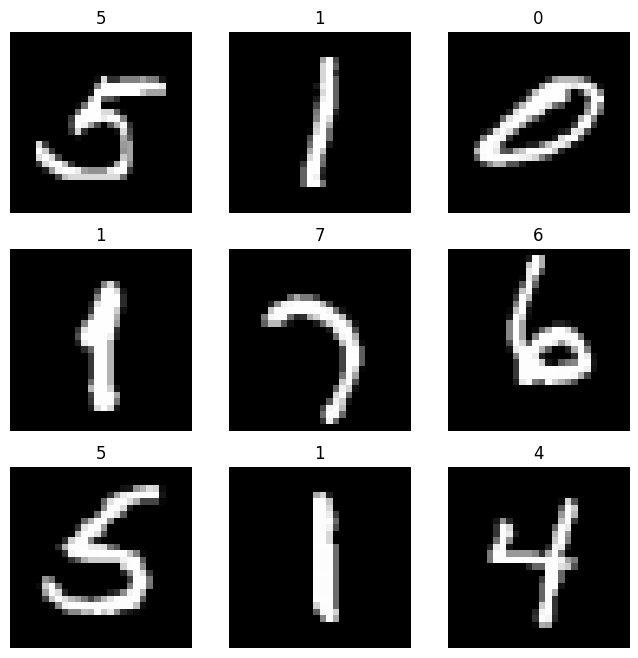

In [4]:
# show some sample images
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

### Model Definition

In [5]:
class MLP(torch.nn.Module):

    def __init__(self, num_features, num_hidden, num_classes):
        super().__init__()
        
        self.num_classes = num_classes
        
        ### 1st hidden layer
        self.linear_1 = torch.nn.Linear(num_features, num_hidden)
        nn.init.kaiming_uniform_(self.linear_1.weight, mode='fan_in', nonlinearity='relu') # initializing the weights 
        nn.init.zeros_(self.linear_1.bias)                                                 # initializing the bias 

        ### Output layer
        self.linear_out = torch.nn.Linear(num_hidden, num_classes)
        nn.init.normal_(self.linear_out.weight, mean=0.0, std=0.1)   # initializing the weights
        nn.init.zeros_(self.linear_out.bias)                         # initializing the bias 
        
    def forward(self, x):
        out = self.linear_1(x)
        out = torch.sigmoid(out)
        logits = self.linear_out(out)
        #probas = torch.softmax(logits, dim=1)
        return logits #, probas

### Model initialization

In [7]:
torch.manual_seed(RANDOM_SEED)

model = MLP(num_features=28*28,
            num_hidden=100,
            num_classes=10)

model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999), eps=1e-8)

In [8]:
print(model)

MLP(
  (linear_1): Linear(in_features=784, out_features=100, bias=True)
  (linear_out): Linear(in_features=100, out_features=10, bias=True)
)


In [9]:
total_params = sum(p.numel() for p in model.parameters())

print(total_params)

79510


### Helper Functions

In [10]:
# Helper function to compute loss

def compute_loss(net, data_loader):
    net.eval() # evaluation mode
    total_loss, total_samples = 0.0, 0
    with torch.no_grad(): # no gradient tracking
        for features, targets in data_loader:
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)
            logits = net(features)
            loss = F.cross_entropy(logits, targets, reduction="sum")  # sum, not mean
            total_loss += loss.item()
            total_samples += targets.size(0)
    return total_loss / total_samples

# Helper function to compute accuracy

def compute_accuracy(net, data_loader):
    net.eval()  # evaluation mode
    correct_pred, num_examples = 0, 0
    with torch.no_grad():  # no gradient tracking
        for features, targets in data_loader:
            features = features.view(-1, 28*28).to(DEVICE)
            targets = targets.to(DEVICE)

            logits = net(features)
            predicted_labels = torch.argmax(logits, dim=1)

            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum().item()

    return correct_pred / num_examples * 100

### Training

In [16]:
start_time = time.time()
minibatch_cost = []
epoch_cost = []
for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        features = features.view(-1, 28*28).to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking = True)
            
        ### FORWARD AND BACK PROP
        logits = model(features)
        
        cost = F.cross_entropy(logits, targets)
        optimizer.zero_grad()
        
        cost.backward()
       
        ### UPDATE MODEL PARAMETERS
        optimizer.step()
        
        ### LOGGING
        minibatch_cost.append(cost.item())
        if not batch_idx % 50:
            print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f' 
                   %(epoch+1, NUM_EPOCHS, batch_idx, 
                     len(train_loader), cost.item()))
        
    cost = compute_loss(model, train_loader)
    epoch_cost.append(cost)
    print('Epoch: %03d/%03d Train Cost: %.4f' % (
            epoch+1, NUM_EPOCHS, cost))
    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/005 | Batch 000/469 | Cost: 0.0167
Epoch: 001/005 | Batch 050/469 | Cost: 0.0273
Epoch: 001/005 | Batch 100/469 | Cost: 0.0250
Epoch: 001/005 | Batch 150/469 | Cost: 0.0340
Epoch: 001/005 | Batch 200/469 | Cost: 0.0160
Epoch: 001/005 | Batch 250/469 | Cost: 0.0417
Epoch: 001/005 | Batch 300/469 | Cost: 0.0709
Epoch: 001/005 | Batch 350/469 | Cost: 0.0254
Epoch: 001/005 | Batch 400/469 | Cost: 0.0802
Epoch: 001/005 | Batch 450/469 | Cost: 0.0242
Epoch: 001/005 Train Cost: 0.0350
Time elapsed: 0.22 min
Epoch: 002/005 | Batch 000/469 | Cost: 0.0276
Epoch: 002/005 | Batch 050/469 | Cost: 0.0598
Epoch: 002/005 | Batch 100/469 | Cost: 0.0412
Epoch: 002/005 | Batch 150/469 | Cost: 0.0413
Epoch: 002/005 | Batch 200/469 | Cost: 0.0696
Epoch: 002/005 | Batch 250/469 | Cost: 0.0263
Epoch: 002/005 | Batch 300/469 | Cost: 0.0940
Epoch: 002/005 | Batch 350/469 | Cost: 0.0735
Epoch: 002/005 | Batch 400/469 | Cost: 0.0346
Epoch: 002/005 | Batch 450/469 | Cost: 0.0621
Epoch: 002/005 Train Co

### Plotting training loss

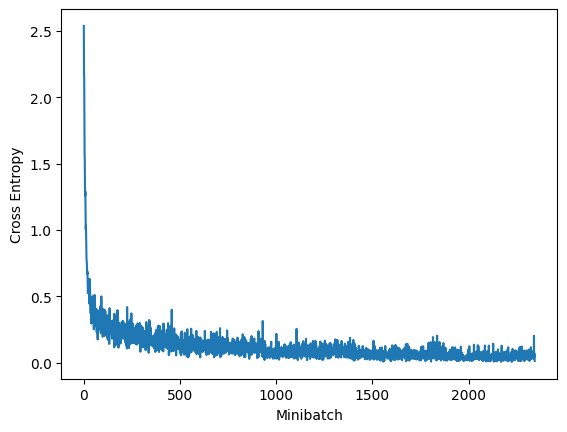

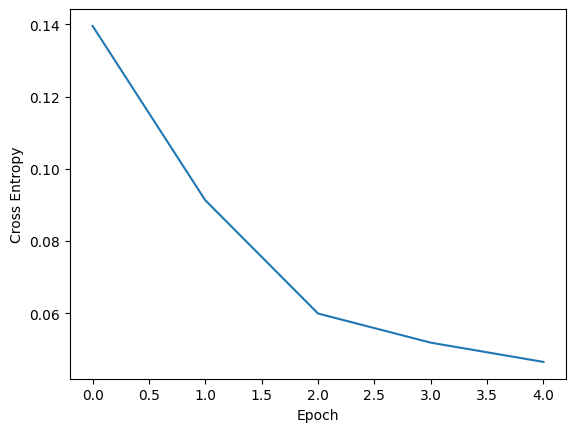

In [12]:
plt.plot(range(len(minibatch_cost)), minibatch_cost)
plt.ylabel('Cross Entropy')
plt.xlabel('Minibatch')
plt.show()

plt.plot(range(len(epoch_cost)), epoch_cost)
plt.ylabel('Cross Entropy')
plt.xlabel('Epoch')
plt.show()

In [13]:
print(f"Training Accuracy: {compute_accuracy(model, train_loader):.2f}%")
print(f"Test Accuracy: {compute_accuracy(model, test_loader):.2f}%")

Training Accuracy: 98.58%
Test Accuracy: 97.11%


In [14]:
def show_examples(model, data_loader):

    for batch_idx, (features, targets) in enumerate(data_loader):

        with torch.no_grad():
            targets = targets.to(DEVICE)
            logits = model(features.view(-1,28*28).to(DEVICE))
            predictions = torch.argmax(logits, dim=1)
        break

    fig, axes = plt.subplots(nrows=3, ncols=5,
                             sharex=True, sharey=True)

    nhwc_img = np.transpose(features.cpu().numpy(), axes=(0, 2, 3, 1))
    nhw_img = np.squeeze(nhwc_img, axis=3)

    for idx, ax in enumerate(axes.ravel()):
        ax.imshow(nhw_img[idx], cmap='gray')
        ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
        ax.axison = False

    plt.tight_layout()
    plt.show()

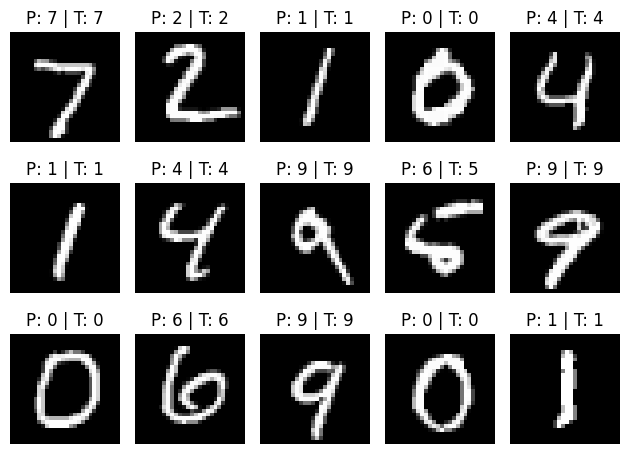

In [15]:
show_examples(model=model, data_loader=test_loader)

In [18]:
if DEVICE == "cuda":
    torch.cuda.empty_cache()    # Release GPU Memory 